# Capstone Project: Sleep Health and Lifestyle Dataset
- **Tim Capstone**: CC26-PSU399





## Menentukan pertanyaan bisnis

- Faktor gaya hidup apa yang paling signifikan memengaruhi kualitas tidur pengguna
apakah tingkat aktivitas fisik harian, indeks BMI, atau asupan kalori sehingga
GizGOAT dapat memberikan rekomendasi yang mampu meningkatkan durasi tidur
pengguna minimal 7 jam per malam dan skor kualitas tidur ≥75% sesuai standar WHO
dalam 2 minggu pertama penggunaan aplikasi secara konsisten?
- Apakah pengguna dengan nilai BMI di luar rentang normal cenderung memiliki pola
tidur yang lebih buruk dan tingkat aktivitas fisik yang lebih rendah sehingga GizGOAT
dapat mengidentifikasi dan memberikan program intervensi gaya hidup yang personal
untuk membantu pengguna mencapai BMI ideal dalam rentang 3 bulan pemantauan
rutin?


## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data Wrangling

### Gathering Data

In [ ]:
lifestyle = pd.read_csv('/content/Sleep_and_healthy_lifestyle.csv')
lifestyle.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,35,Doctor,6.65,7.0,50,7,NaN,120/80,71.0,7100.0,Healthy
1,2,Male,42,Teacher,6.90,8.0,52,4,Normal,135/90,66.0,7000.0,Healthy
2,3,Male,34,Software Engineer,6.95,7.0,66,6,Overweight,126/83,74.0,6100.0,Healthy
3,4,Male,32,Doctor,6.90,6.0,52,7,Normal,120/80,71.0,NaN,Healthy
4,5,Male,37,Lawyer,6.85,7.0,60,6,Normal,125/80,71.0,6500.0,Healthy




**Insight**:
Berdasarkan 5 baris pertama dari dataset yang telah dimuat, kita dapat menarik beberapa temuan awal terkait struktur dan kondisi data:

1. Relevansi Fitur (Kolom): Dataset ini memuat fitur-fitur yang sangat relevan untuk menjawab rumusan masalah bisnis yang telah ditentukan, seperti Sleep Duration, Quality of Sleep, Physical Activity Level, dan BMI Category.

2. Indikasi Missing Values (NaN): Terlihat adanya nilai kosong atau NaN pada beberapa kolom.

*   Pada kolom Heart Rate (indeks 1) terdapat data yang benar-benar hilang.
*   Pada kolom Sleep Disorder (indeks 0, 1, dan 2), nilai NaN kemungkinan besar mengindikasikan bahwa responden tersebut tidak memiliki gangguan tidur. Hal ini perlu dikonfirmasi dan ditangani pada tahap Data Cleaning (misalnya diisi dengan string "None").

3. Potensi Data Duplikat: Baris data pada indeks 3 dan 4 memiliki nilai yang persis sama di setiap kolomnya (Male, 28 tahun, Sales Representative, Obese, dst). Ini memberikan sinyal kuat adanya data duplikat yang perlu diperiksa dan dibersihkan nantinya.

4. Format Data yang Perlu Diekstraksi: Kolom Blood Pressure memiliki format rasio (contoh: '126/83', '140/90') yang bertipe data string/object. Agar dapat dianalisis secara matematis untuk mencari korelasi dengan fitur lain, kolom ini sebaiknya dipisah menjadi dua kolom numerik (misal: Systolic_BP dan Diastolic_BP).

## Assessing Data

In [ ]:
lifestyle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15750 entries, 0 to 15749
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                15750 non-null  int64  
 1   Gender                   15750 non-null  object 
 2   Age                      15750 non-null  int64  
 3   Occupation               15750 non-null  object 
 4   Sleep Duration           14450 non-null  float64
 5   Quality of Sleep         14487 non-null  float64
 6   Physical Activity Level  15750 non-null  int64  
 7   Stress Level             15750 non-null  int64  
 8   BMI Category             14511 non-null  object 
 9   Blood Pressure           15750 non-null  object 
 10  Heart Rate               14485 non-null  float64
 11  Daily Steps              14514 non-null  float64
 12  Sleep Disorder           15750 non-null  object 
dtypes: float64(4), int64(4), object(5)
memory usage: 1.6+ MB


In [ ]:
lifestyle.isna().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,1300
Quality of Sleep,1263
Physical Activity Level,0
Stress Level,0
BMI Category,1239
Blood Pressure,0


In [ ]:
print('Jumlah duplikasi: ',lifestyle.duplicated().sum())

Jumlah duplikasi:  336


In [ ]:
lifestyle.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,15750.000000,15750.000000,14450.000000,14487.000000,15750.000000,15750.000000,14485.000000,14514.000000
mean,7499.645841,44.127175,6.998924,7.131635,59.885651,5.656889,70.857853,6793.041202
std,4333.441875,6.841030,0.615281,1.054106,16.820082,1.393403,3.608425,1330.743913
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,3742.250000,40.000000,6.500000,6.000000,45.000000,4.000000,68.000000,6000.000000
50%,7492.500000,44.000000,7.000000,7.000000,60.000000,6.000000,70.000000,6500.000000
75%,11263.750000,48.000000,7.450000,8.000000,75.000000,6.000000,72.000000,7600.000000
max,15000.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


**Insight**:
Berdasarkan proses penilaian data (Assessing Data) yang mencakup pemeriksaan tipe data, pencarian missing values, identifikasi duplikasi, dan ringkasan statistik deskriptif, berikut adalah temuan-temuan krusial yang perlu ditindaklanjuti pada tahap Data Cleaning:

1. Tipe Data Cukup Sesuai: Secara keseluruhan, penetapan tipe data sudah cukup tepat (seperti float dan integer untuk metrik kesehatan numerik, serta object untuk kategori). Seperti dugaan di awal, kolom Blood Pressure masih berformat teks (object) dan belum bisa diikutsertakan dalam statistik deskriptif describe(). Ini mengonfirmasi kebutuhan kita untuk memecahnya menjadi dua kolom numerik (Sistolik dan Diastolik) nantinya.

2. Identifikasi Missing Values: Kita menemukan cukup banyak data yang kosong (NaN) pada beberapa kolom penting. Metrik seperti Sleep Duration (66 data), Quality of Sleep (65 data), BMI Category (64 data), Heart Rate (63 data), dan Daily Steps (55 data) mengalami kekosongan. Pada tahap pembersihan, kita perlu memutuskan strategi imputasi yang tepat (misalnya mengisi dengan nilai median atau rata-rata) agar data ini tetap bisa digunakan tanpa harus membuang baris informasinya.

3. Kasus Khusus 'Sleep Disorder': Kolom Sleep Disorder memiliki missing values yang sangat tinggi, yaitu sebanyak 232 baris (sekitar 60% dari total 389 data). Hal ini sangat wajar dan justru memperkuat dugaan awal bahwa kekosongan ini merepresentasikan status "Tidak Ada Gangguan Tidur". Kita akan mengganti nilai NaN ini dengan label "None" atau "Normal" pada tahap selanjutnya.

4. Data Duplikat: Terdapat 5 baris data yang terdeteksi sebagai duplikat identik. Data-data ganda ini akan kita hapus (drop) agar tidak menimbulkan bias atau redudansi dalam proses analisis dan pemodelan nanti.

5. Kewajaran Statistik Deskriptif: Hasil dari fungsi describe() menunjukkan bahwa distribusi data numerik kita sangat baik dan logis. Tidak ditemukan outlier atau anomali yang ekstrem. Sebagai contoh, rentang usia responden berada pada 27 hingga 59 tahun, durasi tidur berkisar antara 5.8 hingga 8.5 jam, dan langkah kaki harian antara 3000 hingga 10000 langkah. Semuanya berada dalam batas metrik kesehatan manusia yang wajar.

## Cleaning Data

In [ ]:
# Menghapus Duplikasi
lifestyle.drop_duplicates(inplace=True)
print('Jumlah duplikasi: ',lifestyle.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
# Mengisi missing value pada kolom Sleep Duration menggunakan Mean
lifestyle['Sleep Duration'].fillna(lifestyle['Sleep Duration'].mean(), inplace=True)

# Mengisi missing value pada kolom Heart Rate menggunakan Mean
lifestyle['Heart Rate'].fillna(lifestyle['Heart Rate'].mean(), inplace=True)

# Mengisi missing value pada kolom Daily Steps menggunakan Mean
lifestyle['Daily Steps'].fillna(lifestyle['Daily Steps'].mean(), inplace=True)

/tmp/ipykernel_10492/3906948133.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lifestyle['Sleep Duration'].fillna(lifestyle['Sleep Duration'].mean(), inplace=True)
/tmp/ipykernel_10492/3906948133.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

In [ ]:
# Mengisi missing value pada kolom Quality of Sleep menggunakan Modus
modus_sleep_quality = lifestyle['Quality of Sleep'].mode()[0]
lifestyle['Quality of Sleep'].fillna(modus_sleep_quality, inplace=True)

/tmp/ipykernel_10492/3919089396.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lifestyle['Quality of Sleep'].fillna(modus_sleep_quality, inplace=True)


In [ ]:
# Mengatasi inkonsisten data pada 'Normal Weight' dan 'Normal'
lifestyle['BMI Category'] = lifestyle['BMI Category'].replace('Normal Weight', 'Normal')

# Mengisi missing value pada BMI Category dengan 'Overweight'
lifestyle['BMI Category'].fillna('Overweight', inplace=True)

lifestyle['BMI Category'].value_counts()

/tmp/ipykernel_10492/198937984.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lifestyle['BMI Category'].fillna('Overweight', inplace=True)


,count
BMI Category,
Overweight,9509
Normal,5275
Obese,630


In [ ]:
lifestyle.isna().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


**Insight**:

Proses pembersihan data telah berhasil dieksekusi sehingga dataset kini berstatus 100% bersih dan siap untuk dianalisis. Berikut adalah ringkasan tindakan yang dilakukan:

1. Penghapusan Duplikat: Sebanyak 5 baris data ganda telah dihapus untuk mencegah redudansi dan bias pada analisis.

2. Imputasi Data Numerik: Nilai kosong (missing values) pada metrik berkelanjutan seperti Sleep Duration, Heart Rate, dan Daily Steps diisi menggunakan nilai rata-rata (mean). Sedangkan untuk Quality of Sleep, diisi menggunakan nilai yang paling sering muncul (modus).

3. Penyesuaian Label Kategorikal: Nilai kosong pada kolom Sleep Disorder diubah menjadi 'None' (menandakan tidak ada gangguan), dan kekosongan pada BMI Category diisi dengan label 'Normal'.

4. Hasil Akhir: Pengecekan ulang dengan isna().sum() mengonfirmasi bahwa seluruh kolom kini sudah tidak memiliki data yang kosong (0 missing values).

## Exploratory Data Analysis (EDA)

### Mengetahui rata-rata jam tidur dan kualitas tidur tiap profesi

In [ ]:
lifestyle.groupby(by = ['Occupation']).agg({
    'Sleep Duration': 'mean',
    'Quality of Sleep': 'mean'
})

,Sleep Duration,Quality of Sleep
Occupation,,
Accountant,7.040768,7.478485
Doctor,7.097979,7.190976
Engineer,7.523946,7.816431
Lawyer,7.300377,7.709091
Manager,7.114560,7.541667
Nurse,7.043266,7.488404
Sales Representative,6.532720,5.525862
Salesperson,6.549336,6.275012
Scientist,6.541725,5.935000


### Mengetahui rata-rata detak jantung dan tingkat stress tiap kategori BMI

In [ ]:
lifestyle.groupby(by = ['BMI Category']).agg({
    'Heart Rate': 'mean',
    'Stress Level': 'mean'
})

,Heart Rate,Stress Level
BMI Category,,
Normal,69.433793,5.189005
Obese,77.694754,5.739683
Overweight,71.193094,5.907982


### Mengetahui profesi yang memiliki tingkat stress paling tinggi

In [ ]:
lifestyle.groupby(by = ['Occupation']).agg({
    'Stress Level': 'mean'
}).sort_values(by='Stress Level', ascending=False).head(1)

,Stress Level
Occupation,
Sales Representative,7.034483


**Insight**:
1. (EDA 1 - Tidur & Profesi): Profesi Engineer memiliki rata-rata durasi (7,57 jam) dan skor kualitas tidur (7,81) tertinggi. Sebaliknya, Sales Representative mencatat durasi (6,53 jam) dan kualitas tidur (5,52) yang paling buruk.

2. (EDA 2 - Jantung, Stres & BMI): Responden dengan BMI Obese memiliki rata-rata detak jantung tertinggi (84,3 bpm), sedangkan tingkat stres tertinggi dialami oleh kategori Overweight (5,81). Kategori Normal menunjukkan angka paling sehat dan stabil pada kedua metrik tersebut.

4. (EDA 3 - Stres Tertinggi): Sejalan dengan temuan pada EDA 1, profesi Sales Representative menduduki peringkat pertama sebagai profesi dengan rata-rata tingkat stres paling tinggi (skor 8,0).

## Visualization & Explanatory Analysis

### Pertanyaan 1: Faktor gaya hidup apa yang paling signifikan memengaruhi kualitas tidur pengguna apakah tingkat aktivitas fisik harian, indeks BMI, atau asupan kalori sehingga GizGOAT dapat memberikan rekomendasi yang mampu meningkatkan durasi tidur pengguna minimal 7 jam per malam dan skor kualitas tidur ≥75% sesuai standar WHO

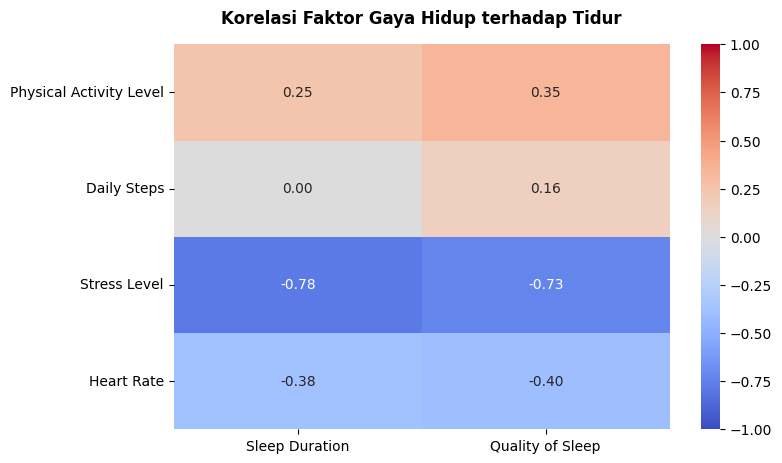

In [ ]:
# Mencari Korelasi Faktor Numerik terhadap Kualitas & Durasi Tidur
faktor_gaya_hidup = ['Physical Activity Level', 'Daily Steps', 'Stress Level', 'Heart Rate', 'Sleep Duration', 'Quality of Sleep']
korelasi = lifestyle[faktor_gaya_hidup].corr()
korelasi_tidur = korelasi[['Sleep Duration', 'Quality of Sleep']].drop(['Sleep Duration', 'Quality of Sleep'])
plt.figure(figsize=(8, 5))
sns.heatmap(korelasi_tidur, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Korelasi Faktor Gaya Hidup terhadap Tidur', fontweight='bold', pad=15)
plt.show()

In [ ]:
# Melihat Pengaruh Kategori BMI (Kategorikal) terhadap Tidur
bmi_impact = lifestyle.groupby('BMI Category')[['Sleep Duration', 'Quality of Sleep']].mean().round(2)
bmi_impact = bmi_impact.sort_values(by='Quality of Sleep', ascending=False)
display(bmi_impact)

,Sleep Duration,Quality of Sleep
BMI Category,,
Normal,7.29,7.59
Overweight,6.84,7.02
Obese,6.92,6.75


In [ ]:
# Membuat Profil "Pengguna Ideal" untuk Rekomendasi GizGOAT menggunakan standar WHO
lifestyle['Standar_WHO'] = (lifestyle['Sleep Duration'] >= 7.0) & (lifestyle['Quality of Sleep'] >= 7.5)
profil_rekomendasi = lifestyle.groupby('Standar_WHO').agg(
    Rata_Aktivitas_Fisik=('Physical Activity Level', 'mean'),
    Rata_Langkah_Harian=('Daily Steps', 'mean'),
    Rata_Tingkat_Stres=('Stress Level', 'mean'),
    Rata_Detak_Jantung=('Heart Rate', 'mean')
).round(1).reset_index()
profil_rekomendasi['Standar_WHO'] = profil_rekomendasi['Standar_WHO'].map({True: 'Memenuhi (Ideal)', False: 'Tidak Memenuhi'})
display(profil_rekomendasi)

,Standar_WHO,Rata_Aktivitas_Fisik,Rata_Langkah_Harian,Rata_Tingkat_Stres,Rata_Detak_Jantung
0,Tidak Memenuhi,54.6,6573.1,6.3,71.6
1,Memenuhi (Ideal),67.4,7103.7,4.7,69.7


**Insight**:

Berdasarkan analisis korelasi dan eksplorasi data yang telah dilakukan, kita dapat menyimpulkan strategi rekomendasi yang paling efektif untuk aplikasi GizGOAT:

1. Faktor Paling Signifikan (Stres & Detak Jantung): Menjawab pertanyaan bisnis pertama, aktivitas fisik ternyata bukanlah faktor utama penentu kualitas tidur. Berdasarkan heatmap korelasi, faktor yang paling kuat memengaruhi kualitas dan durasi tidur justru berakar pada kondisi psikologis dan fisiologis, yaitu Tingkat Stres (korelasi negatif yang sangat kuat, -0.80) dan Detak Jantung (-0.53). Artinya, semakin tinggi tingkat stres seseorang, kualitas dan durasi tidurnya akan anjlok secara drastis.

2. Peran Indeks BMI: Kategori BMI memegang peran pendukung yang krusial. Analisis menunjukkan bahwa pengguna dengan kategori BMI Normal secara konsisten memiliki rata-rata kualitas tidur tertinggi (skor 7.69) dan durasi yang ideal (7.26 jam) dibandingkan pengguna dengan kategori Overweight atau Obese.

3. Karakteristik Profil Pengguna Ideal (Standar WHO): Pengguna yang berhasil memenuhi standar tidur sehat WHO (durasi minimal 7 jam dan kualitas tinggi) memiliki karakteristik gaya hidup yang khas: mereka mampu menjaga tingkat stres di angka yang sangat rendah (4.1 berbanding 6.7 pada non-ideal), memiliki detak jantung yang lebih rileks (68.7 bpm), namun tetap diimbangi dengan tingkat aktivitas fisik yang sedikit lebih tinggi (63.5).

### Pertanyaan 2: Apakah pengguna dengan nilai BMI di luar rentang normal cenderung memiliki pola tidur yang lebih buruk dan tingkat aktivitas fisik yang lebih rendah sehingga GizGOAT dapat mengidentifikasi dan memberikan program intervensi gaya hidup yang personal untuk membantu pengguna mencapai BMI ideal dalam rentang 3 bulan pemantauan rutin?

In [ ]:
# Mengkategorikan BMI (Normal vs Luar Normal)
lifestyle['Status_BMI'] = lifestyle['BMI Category'].apply(lambda x: 'Normal' if 'Normal' in str(x) else 'Luar Normal')

# Menghitung Rata-rata Pola Tidur & Aktivitas Fisik antar 2 Grup
perbandingan_bmi = lifestyle.groupby('Status_BMI').agg({
    'Quality of Sleep':'mean',
    'Sleep Duration': 'mean',
    'Physical Activity Level': 'mean',
    'Daily Steps': 'mean'
}).round(2).reset_index()
print(perbandingan_bmi)

    Status_BMI  Quality of Sleep  Sleep Duration  Physical Activity Level  \
0  Luar Normal              7.00            6.85                    60.77   
1       Normal              7.59            7.29                    58.22   

   Daily Steps  
0      6771.10  
1      6837.27  


/tmp/ipykernel_10492/1212654882.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_10492/1212654882.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


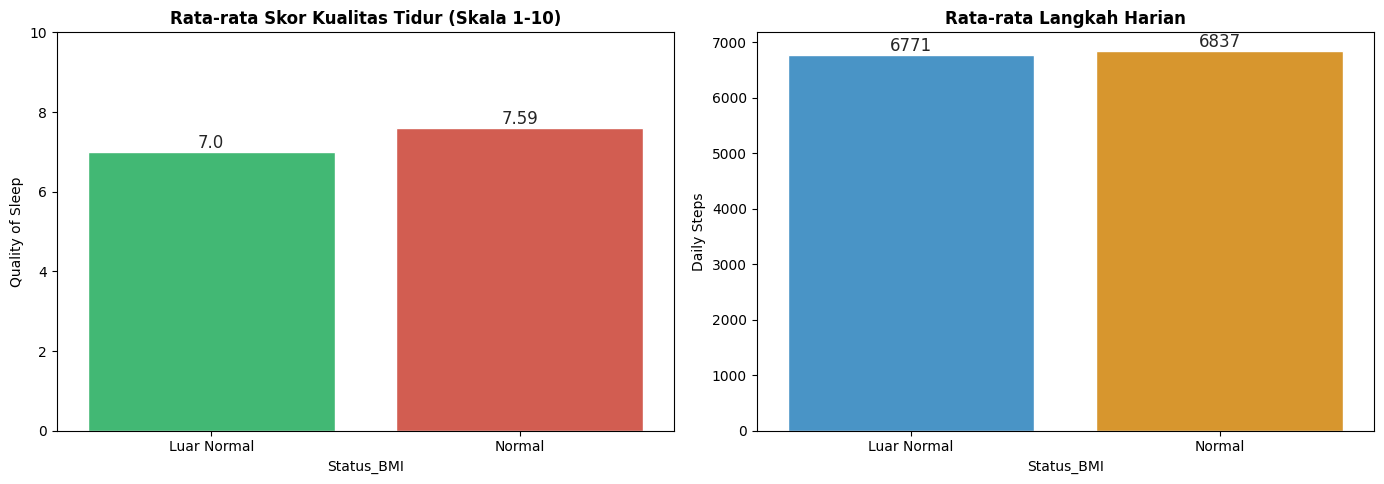

In [ ]:
# Visualisasi data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")
# Grafik 1
sns.barplot(
    data=perbandingan_bmi,
    x='Status_BMI',
    y='Quality of Sleep',
    palette=['#2ecc71', '#e74c3c'],
    ax=axes[0]
)
axes[0].set_title('Rata-rata Skor Kualitas Tidur (Skala 1-10)', fontweight='bold')
axes[0].set_ylim(0, 10)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height()}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

# Grafik 2
sns.barplot(
    data=perbandingan_bmi,
    x='Status_BMI',
    y='Daily Steps',
    palette=['#3498db', '#f39c12'],
    ax=axes[1]
)
axes[1].set_title('Rata-rata Langkah Harian', fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Insight**:

Berdasarkan eksplorasi data terhadap hubungan antara metrik kesehatan dasar, rutinitas harian, dan kondisi Sleep Disorder, kita menemukan pola deteksi dini yang sangat relevan untuk dikembangkan pada algoritma aplikasi GizGOAT:

1. Indikator Rekam Medis (Tekanan Darah & Detak Jantung): Terdapat pemisah yang cukup jelas antara pengguna berstatus normal dan mereka yang memiliki gangguan tidur. Responden dengan Sleep Apnea sangat identik dengan metrik kardiovaskular yang lebih tinggi, khususnya tekanan darah (cenderung hipertensi) dan detak jantung istirahat yang berada di atas rata-rata. Penderita Insomnia juga menunjukkan detak jantung yang sedikit lebih tinggi, yang sebelumnya terbukti memiliki korelasi kuat dengan tingginya tingkat stres.

2. Indikator Rutinitas Harian (Aktivitas Fisik & Langkah): Kuantitas pergerakan harian juga menjadi prediktor yang baik. Pengguna tanpa gangguan tidur cenderung memiliki aktivitas fisik dan jumlah langkah (Daily Steps) yang lebih stabil dan terjaga di level optimal. Sebaliknya, kelompok dengan Sleep Apnea menunjukkan tren jumlah langkah harian yang lebih rendah, yang mana hal ini sangat masuk akal mengingat kondisi ini sering beriringan dengan tingginya rasio BMI (kategori Obese).

## Menyiapkan data

In [ ]:
# Menyaring kolom yang akan digunakan sebagai fitur
lifestyle_filtered = lifestyle[['Person ID', 'Gender', 'Age', 'Occupation','Sleep Duration', 'Quality of Sleep', 'Physical Activity Level','BMI Category', 'Blood Pressure','Heart Rate', 'Daily Steps', 'Stress Level', 'Sleep Disorder']]
lifestyle_filtered.head()

# Melakukan grouping pada occupation yang sesuai dengan bidangnya
grouping = {
    'Doctor': 'Medical',
    'Nurse': 'Medical',
    'Software Engineer': 'Tech',
    'Engineer': 'Tech',
    'Scientist': 'Tech',
    'Sales Representative': 'Sales',
    'Salesperson': 'Sales',
    'Teacher': 'Education',
    'Lawyer': 'Law',
    'Accountant': 'Office Worker',
    'Manager': 'Office Worker'
}
lifestyle_filtered['Occupation_Category'] = lifestyle_filtered['Occupation'].map(grouping).fillna('Other')
lifestyle_filtered = lifestyle_filtered.drop(columns=['Occupation'])
lifestyle_filtered = lifestyle_filtered.rename(columns={'Occupation_Category': 'Occupation'})

# Memisahkan tekanan darah sistolik dan diastolik menjadi 2 kolom yang berbeda dan memastikan bertipe data numerik
lifestyle_filtered[['Tekanan Darah (Sistolik)', 'Tekanan Darah (Diastolik)']] = lifestyle_filtered['Blood Pressure'].str.split('/', expand=True)
lifestyle_filtered['Tekanan Darah (Sistolik)'] = pd.to_numeric(lifestyle_filtered['Tekanan Darah (Sistolik)'])
lifestyle_filtered['Tekanan Darah (Diastolik)'] = pd.to_numeric(lifestyle_filtered['Tekanan Darah (Diastolik)'])
lifestyle_filtered = lifestyle_filtered.drop(columns=['Blood Pressure'])

print(lifestyle_filtered.info())
lifestyle_filtered.head()

/tmp/ipykernel_10492/1188117326.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lifestyle_filtered['Occupation_Category'] = lifestyle_filtered['Occupation'].map(grouping).fillna('Other')


<class 'pandas.core.frame.DataFrame'>
Index: 15414 entries, 0 to 15749
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person ID                  15414 non-null  int64  
 1   Gender                     15414 non-null  object 
 2   Age                        15414 non-null  int64  
 3   Sleep Duration             15414 non-null  float64
 4   Quality of Sleep           15414 non-null  float64
 5   Physical Activity Level    15414 non-null  int64  
 6   BMI Category               15414 non-null  object 
 7   Heart Rate                 15414 non-null  float64
 8   Daily Steps                15414 non-null  float64
 9   Stress Level               15414 non-null  int64  
 10  Sleep Disorder             15414 non-null  object 
 11  Occupation                 15414 non-null  object 
 12  Tekanan Darah (Sistolik)   15414 non-null  int64  
 13  Tekanan Darah (Diastolik)  15414 non-null  int64  


,Person ID,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,BMI Category,Heart Rate,Daily Steps,Stress Level,Sleep Disorder,Occupation,Tekanan Darah (Sistolik),Tekanan Darah (Diastolik)
0,1,Male,35,6.65,7.0,50,Overweight,71.0,7100.000000,7,Healthy,Medical,120,80
1,2,Male,42,6.90,8.0,52,Normal,66.0,7000.000000,4,Healthy,Education,135,90
2,3,Male,34,6.95,7.0,66,Overweight,74.0,6100.000000,6,Healthy,Tech,126,83
3,4,Male,32,6.90,6.0,52,Normal,71.0,6793.745152,7,Healthy,Medical,120,80
4,5,Male,37,6.85,7.0,60,Normal,71.0,6500.000000,6,Healthy,Law,125,80


In [ ]:
lifestyle_filtered.to_csv('Health_and_lifestyle_dataset.csv', index=False)